## Análisis de Datos Meteorológicos con una API Pública
Obtener datos del clima de una ciudad usando la API de Open-Meteo (https://open-meteo.com/) y mostrar el pronóstico para Bilbao.

* Haz una petición a la API para que devuelva el pronóstico de las temperaturas para una semana en Bilbao. Tip: el parámetro correspondiente en el query es `temperature_2m` además de la latitud y la longitud.
* Procesa la respuesta en formato JSON para obtener dos listas: una con la lista de temperaturas y otra con las fechas-horas correspondientes.
* Crea un DataFrame con esas dos columnas: `Hora` y `Temperatura`
* Elige la gráfica adecuada y visualiza el pronóstico de temperaturas.

Para crear la variable `Hora` del DataFrame puedes introducir directamente la lista que se obtiene del campo `data["hourly"]["time"]` o procesar esa lista mediante el siguiente código:

`hours = pd.date_range(start=lista_de_horas, periods=len(temps), freq="H")`

In [12]:
import requests

# Coordenadas de Kuna en Bilbao
latitude = 43.2540
longitude = -2.9230

url = f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&hourly=temperature_2m"

In [ ]:
#response = requests.get(url)
json = response.json()

In [ ]:
hours = json["hourly"]["time"]
temperatures = json["hourly"]["temperature_2m"]

In [17]:
import pandas as pd

forecast = pd.DataFrame({
    "hour": hours,
    "temperature": temperatures
})
forecast

,hour,temperature
0,2026-03-23T00:00,12.3
1,2026-03-23T01:00,12.1
2,2026-03-23T02:00,11.8
3,2026-03-23T03:00,11.5
4,2026-03-23T04:00,11.1
...,...,...
163,2026-03-29T19:00,8.6
164,2026-03-29T20:00,8.5
165,2026-03-29T21:00,8.4
166,2026-03-29T22:00,8.4


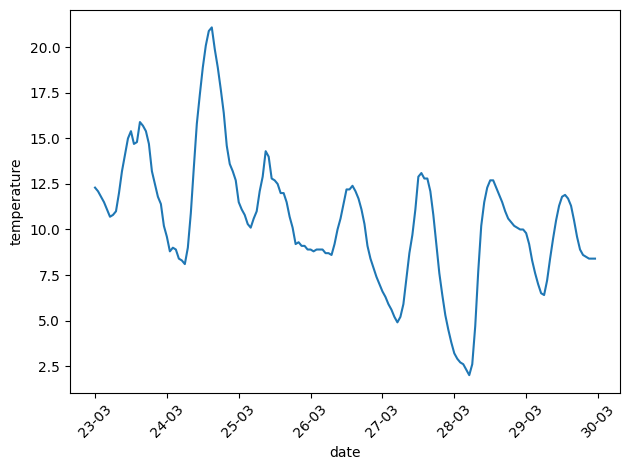

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

daily = forecast.copy()
daily["date"] = pd.to_datetime(forecast["hour"])

ax = sns.lineplot(x="date", y="temperature", data=daily)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))

plt.xticks(rotation=45)
plt.tight_layout();